In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
transactions = pd.read_csv("transaction_data.csv")
products = pd.read_csv("product.csv")
campaigns = pd.read_csv("campaign_table.csv")
campaign_desc = pd.read_csv("campaign_desc.csv")
coupon = pd.read_csv("coupon.csv")
coupon_redempt = pd.read_csv("coupon_redempt.csv")
hh_demographics = pd.read_csv("hh_demographic.csv")
causal_data = pd.read_csv("causal_data.csv")


In [3]:
transactions.info()
transactions.describe()
transactions.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

In [4]:
transactions['DAY'] = transactions['DAY'].astype('int8')
transactions['QUANTITY'] = transactions['QUANTITY'].astype('int8')
transactions['WEEK_NO'] = transactions['WEEK_NO'].astype('int8')
transactions['TRANS_TIME'] = transactions['TRANS_TIME'].astype('int16')
transactions['SALES_VALUE'] = transactions['SALES_VALUE'].astype('float32')
transactions['RETAIL_DISC'] = transactions['RETAIL_DISC'].astype('float32')
transactions['COUPON_DISC'] = transactions['COUPON_DISC'].astype('float32')
transactions['COUPON_MATCH_DISC'] = transactions['COUPON_MATCH_DISC'].astype('float32')


In [5]:
transactions['TOTAL_DISCOUNT'] = transactions['RETAIL_DISC'] + transactions['COUPON_DISC'] + transactions['COUPON_MATCH_DISC']


In [6]:
transactions['EFFECTIVE_PRICE'] = transactions['SALES_VALUE'] / transactions['QUANTITY']


In [7]:
transactions['DISCOUNT_PCT'] = transactions['TOTAL_DISCOUNT'] / (transactions['SALES_VALUE'] + transactions['TOTAL_DISCOUNT'])
transactions['DISCOUNT_PCT'] = transactions['DISCOUNT_PCT'].fillna(0)


In [8]:
transactions.drop_duplicates(inplace=True)


In [9]:
transactions.fillna(0, inplace=True)  


In [10]:
transactions = transactions[(transactions['QUANTITY'] > 0) & (transactions['SALES_VALUE'] >= 0)]


In [11]:
transactions['household_key'] = transactions['household_key'].astype('str')
transactions['PRODUCT_ID'] = transactions['PRODUCT_ID'].astype('str')
transactions['STORE_ID'] = transactions['STORE_ID'].astype('str')
transactions['BASKET_ID'] = transactions['BASKET_ID'].astype('str')


In [12]:
transactions.sort_values(by=['household_key', 'BASKET_ID', 'TRANS_TIME'], inplace=True)


In [13]:
store_dummies = pd.get_dummies(transactions['STORE_ID'], prefix='store')
transactions = pd.concat([transactions, store_dummies], axis=1)


In [14]:
daily_metrics = transactions.groupby('DAY').agg(
    num_transactions=('BASKET_ID', 'nunique'),
    total_sales=('SALES_VALUE', 'sum'),
    total_quantity=('QUANTITY', 'sum'),
    total_coupon_discount=('COUPON_DISC', 'sum'),
    distinct_stores=('STORE_ID', 'nunique'),
    distinct_households=('household_key', 'nunique')
).reset_index()

daily_metrics['avg_transaction_value'] = (daily_metrics['total_sales'] / daily_metrics['num_transactions']).round(2)
daily_metrics['avg_basket_size'] = (daily_metrics['total_quantity'] / daily_metrics['num_transactions']).round(2)

daily_metrics = daily_metrics.sort_values('DAY')


In [15]:
daily_metrics

,DAY,num_transactions,total_sales,total_quantity,total_coupon_discount,distinct_stores,distinct_households,avg_transaction_value,avg_basket_size
0,-128,1271,40166.378906,19806,-122.180000,124,838,31.60,15.58
1,-127,1311,41247.828125,19933,-115.639999,127,854,31.46,15.20
2,-126,1347,37968.839844,19169,-106.300003,131,875,28.19,14.23
3,-125,882,24258.189453,13635,-92.389999,121,639,27.50,15.46
4,-124,1198,38194.109375,20598,-103.129997,134,821,31.88,17.19
...,...,...,...,...,...,...,...,...,...
251,123,1275,34579.808594,19450,-192.029999,126,817,27.12,15.25
252,124,1269,35667.250000,18487,-104.669998,126,819,28.11,14.57
253,125,1218,33520.691406,18245,-115.269997,127,794,27.52,14.98
254,126,1199,34158.390625,18371,-138.179993,131,803,28.49,15.32


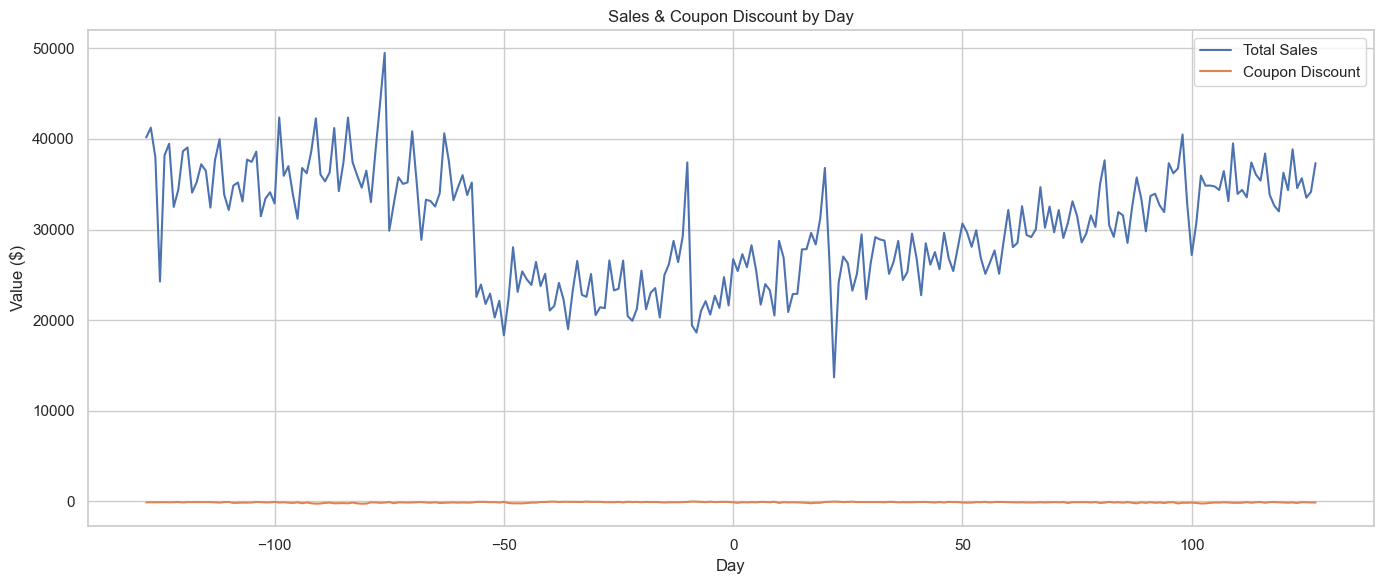

In [16]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="total_sales", label="Total Sales")
sns.lineplot(data=daily_metrics, x="DAY", y="total_coupon_discount", label="Coupon Discount")
plt.title("Sales & Coupon Discount by Day")
plt.xlabel("Day")
plt.ylabel("Value ($)")
plt.legend()
plt.tight_layout()
plt.show()

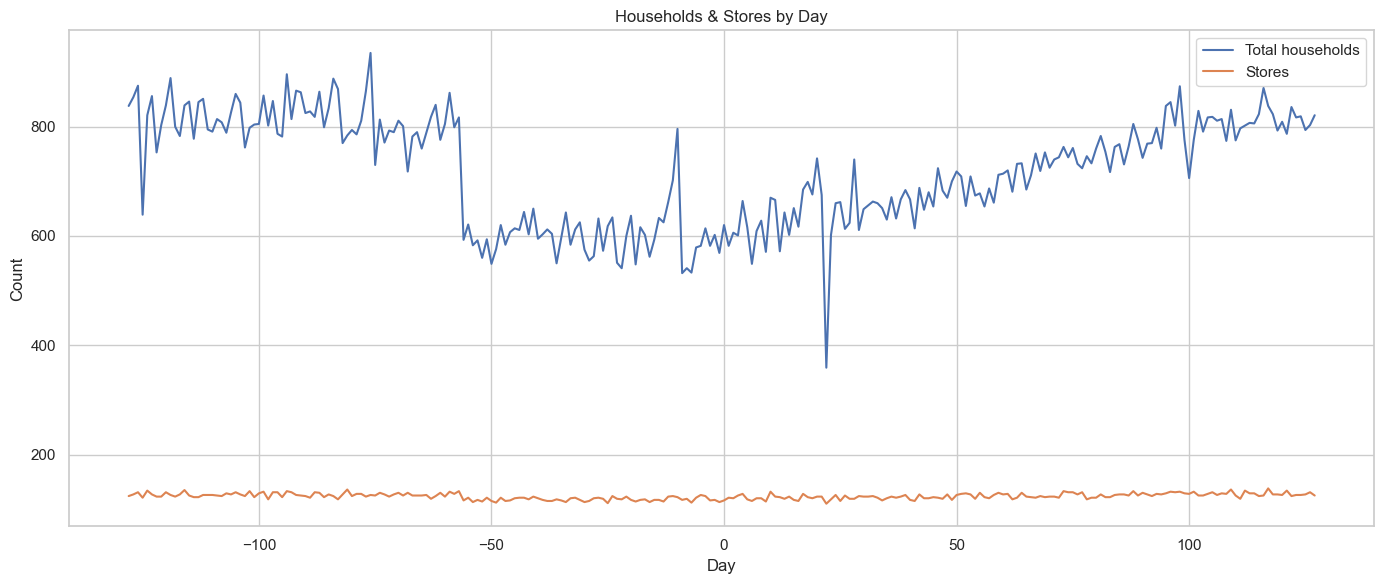

In [17]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_households", label="Total households")
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_stores", label="Stores")
plt.title("Households & Stores by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

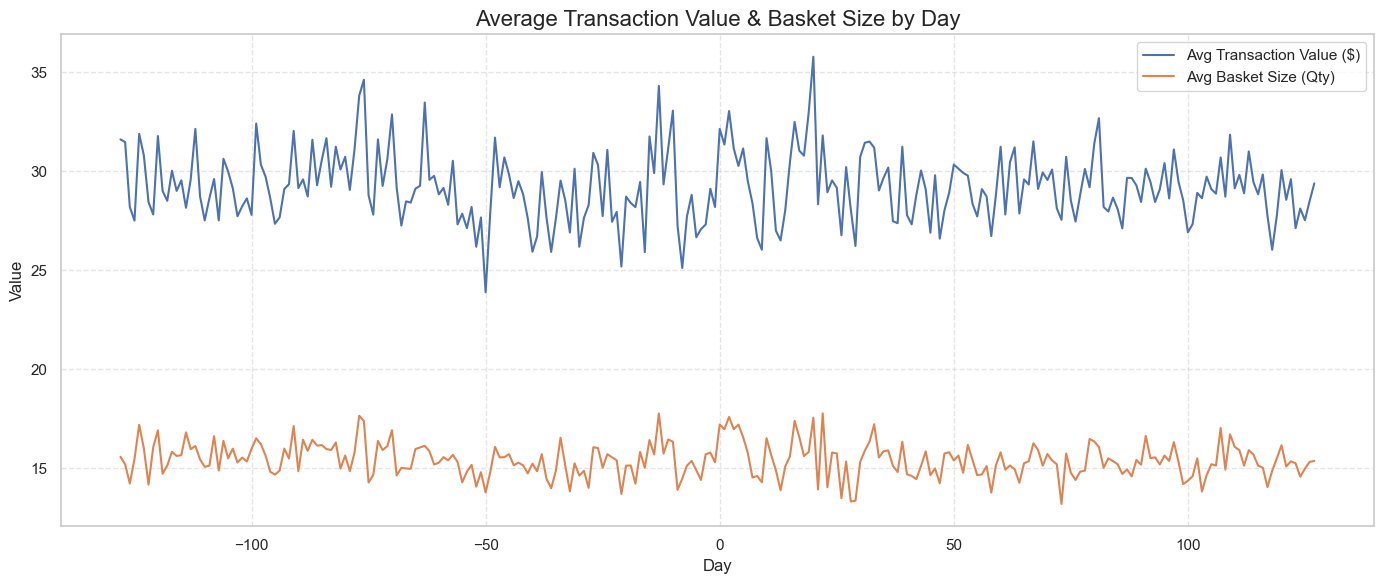

In [18]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_metrics, x="DAY", y="avg_transaction_value", label="Avg Transaction Value ($)")
sns.lineplot(data=daily_metrics, x="DAY", y="avg_basket_size", label="Avg Basket Size (Qty)")

plt.title("Average Transaction Value & Basket Size by Day", fontsize=16)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
transaction_aggregate = pd.DataFrame({
    'households': [transactions['household_key'].nunique()],
    'baskets': [transactions['BASKET_ID'].nunique()],
    'days': [transactions['DAY'].nunique()]
})
print(transaction_aggregate)


   households  baskets  days
0        2500   264631   256


In [20]:
transaction_aggregate2 = hh_demographics[['household_key']].drop_duplicates().sort_values('household_key').reset_index(drop=True)


In [21]:
transaction_aggregate2

,household_key
0,1
1,7
2,8
3,13
4,16
...,...
796,2494
797,2496
798,2497
799,2498


0    368063.613281
1      2109.059967
2     65778.596191
3    542311.413086
4    367380.000000
Name: LoyaltyScore, dtype: float64


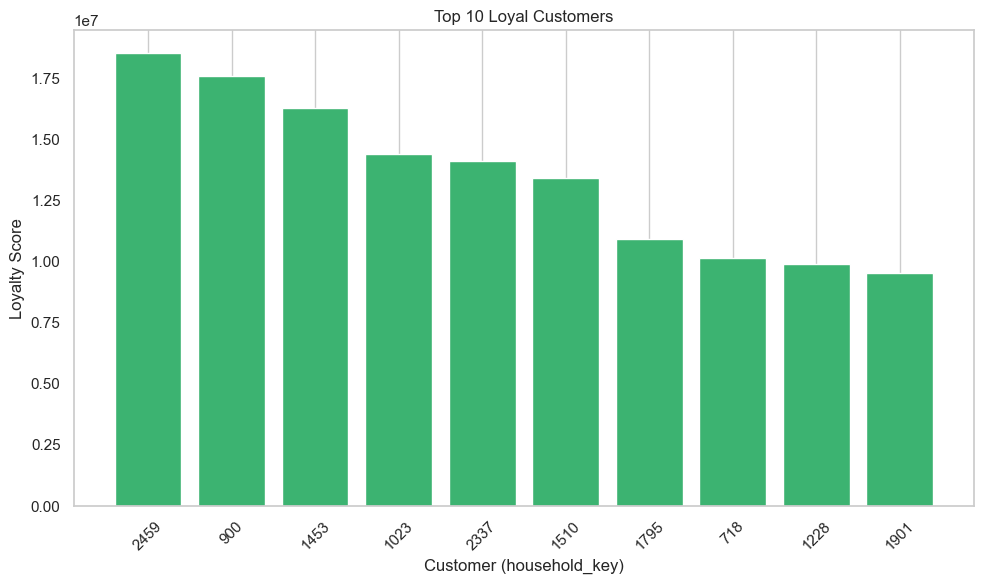

In [22]:
basket_summary = transactions.groupby(['household_key', 'BASKET_ID']).agg({
    'SALES_VALUE': 'sum',
    'DAY': 'min',
    'WEEK_NO': 'min'
}).reset_index()

customer_summary = basket_summary.groupby('household_key').agg({
    'BASKET_ID': 'nunique',
    'SALES_VALUE': 'sum',
    'WEEK_NO': ['min', 'max', 'nunique']
}).reset_index()

customer_summary.columns = ['household_key', 'TotalBaskets', 'TotalSpent', 'FirstWeek', 'LastWeek', 'ActiveWeeks']
#loyality score = customer total spent * totalbaskets
customer_summary['LoyaltyScore'] = customer_summary['TotalSpent'] * customer_summary['TotalBaskets']

top_customers = customer_summary.sort_values('LoyaltyScore', ascending=False).head(10)

print(customer_summary['LoyaltyScore'].head())
plt.figure(figsize=(10, 6))
plt.bar(top_customers['household_key'].astype(str), top_customers['LoyaltyScore'], color='mediumseagreen')
plt.xlabel('Customer (household_key)')
plt.ylabel('Loyalty Score')
plt.title('Top 10 Loyal Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()



Customer Loyalty Summary:
  household_key  TotalBaskets   TotalSpent  FirstWeek  LastWeek  ActiveWeeks  \
0             1            85  4330.160156          8       102           68   
1            10             9   234.339996         17        99            5   
2           100            30  2192.619873          2        99           25   
3          1000           134  4047.100098          8       102           77   
4          1001            90  4082.000000          3       102           51   

    LoyaltyScore  
0  368063.613281  
1    2109.059967  
2   65778.596191  
3  542311.413086  
4  367380.000000  


C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2320610696.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers['household_key'].astype(str), y=top_customers['LoyaltyScore'], palette="viridis")


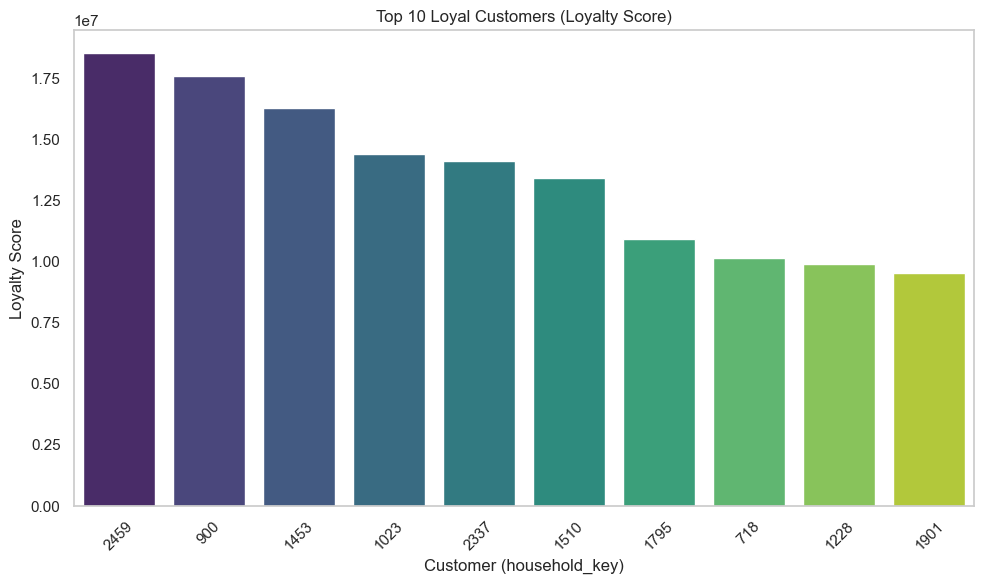

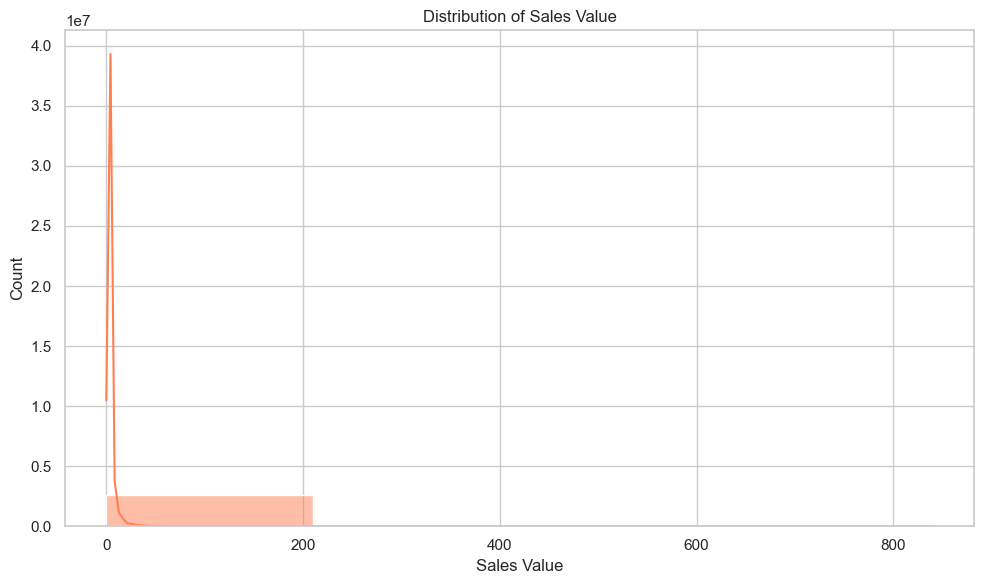

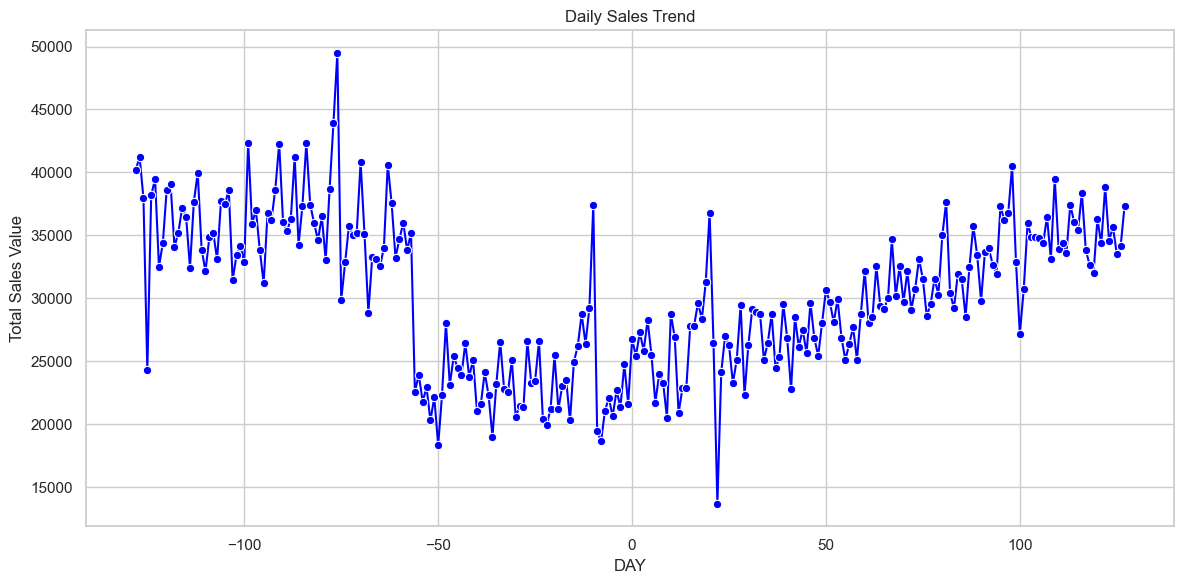

C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2320610696.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products['PRODUCT_ID'].astype(str), y=top_products['QUANTITY'], palette="magma")


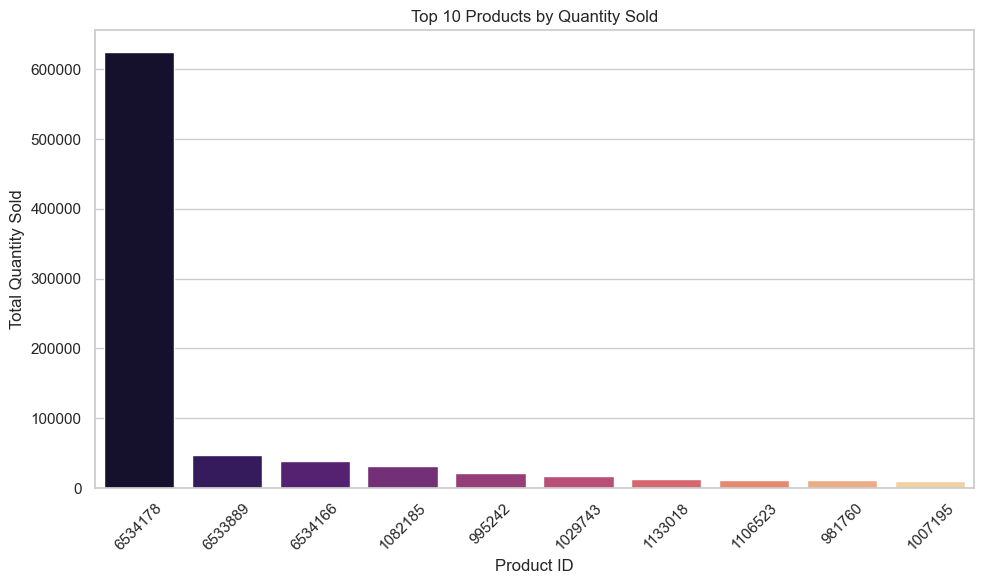

C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2320610696.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\gratu\anaconda3\envs\ML\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


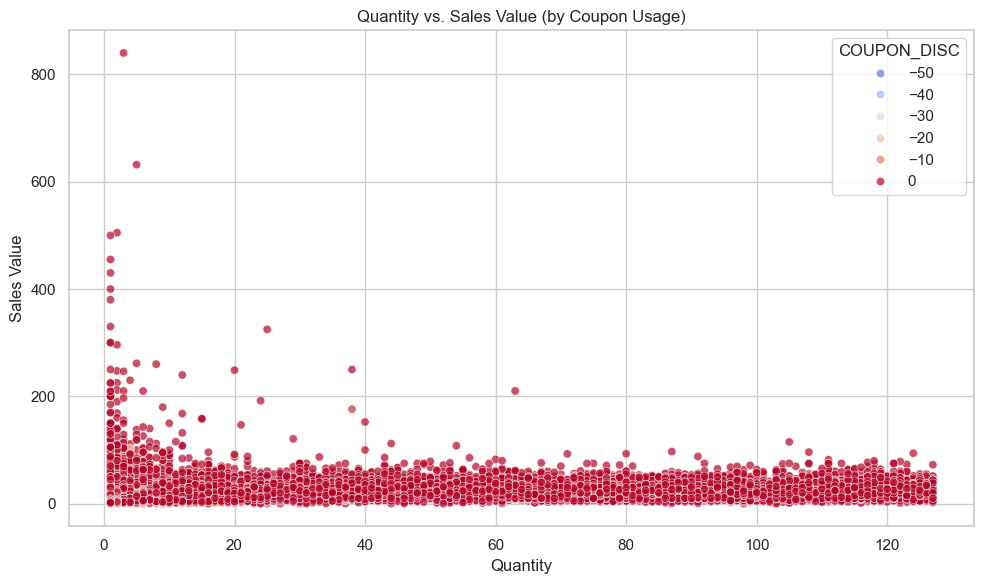

C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2320610696.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TimeOfDay', data=transactions, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='Set2')


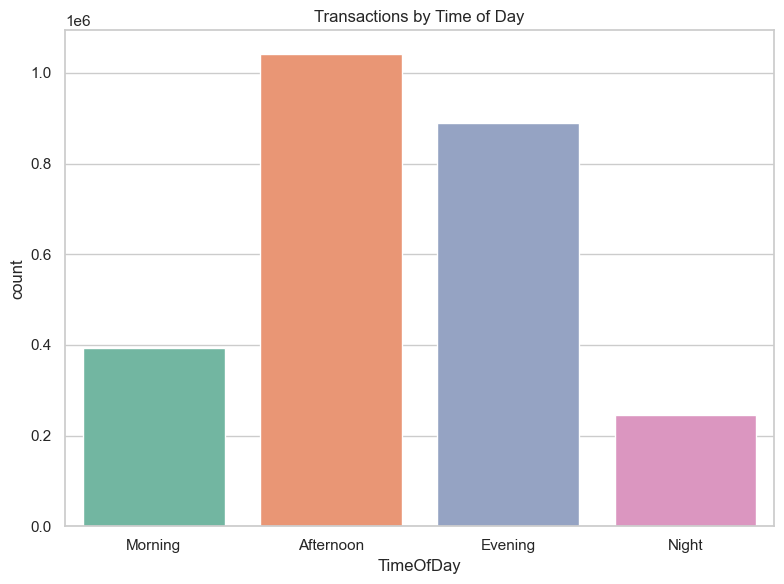

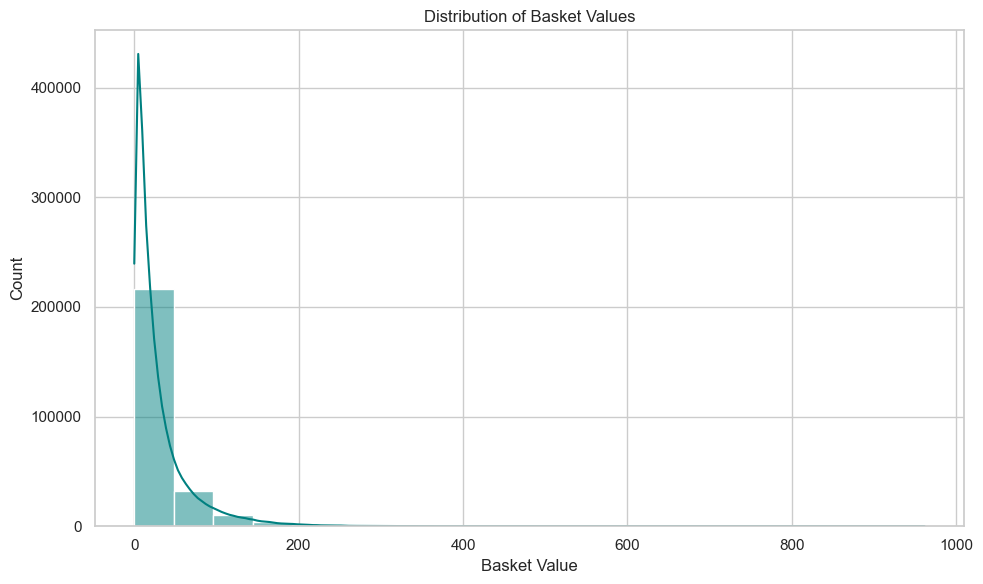

C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2320610696.py:105: RuntimeWarning: overflow encountered in scalar subtract
  customer_rfm[['Recency_norm', 'Frequency_norm', 'Monetary_norm']] = customer_rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: (x - x.min()) / (x.max() - x.min()))


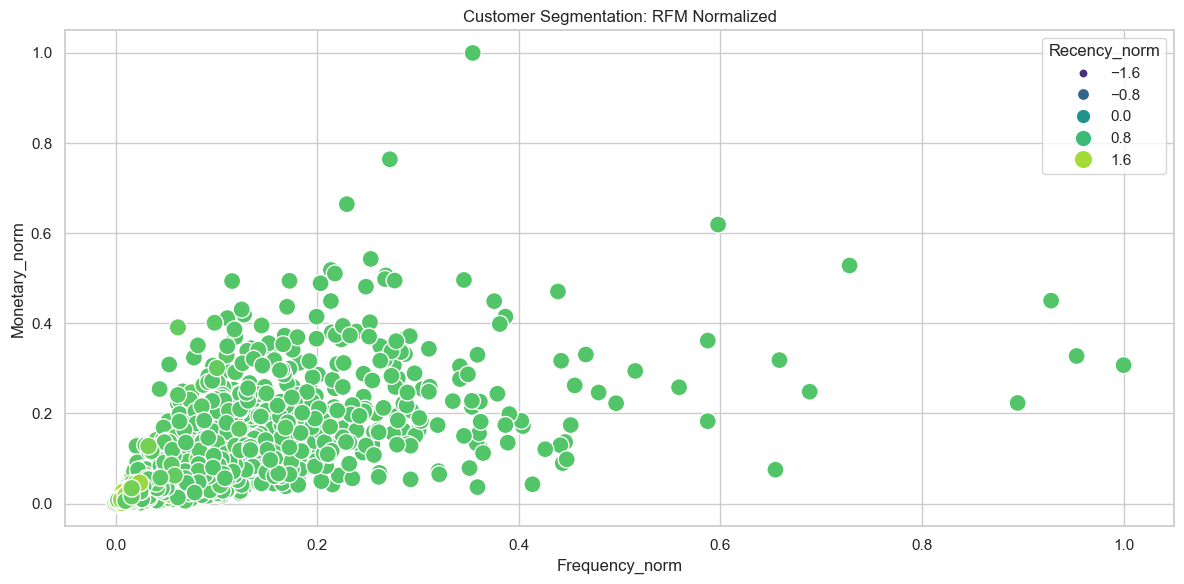

C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2320610696.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_stats, x='PRODUCT_ID', y='IsDiscounted', palette='coolwarm')


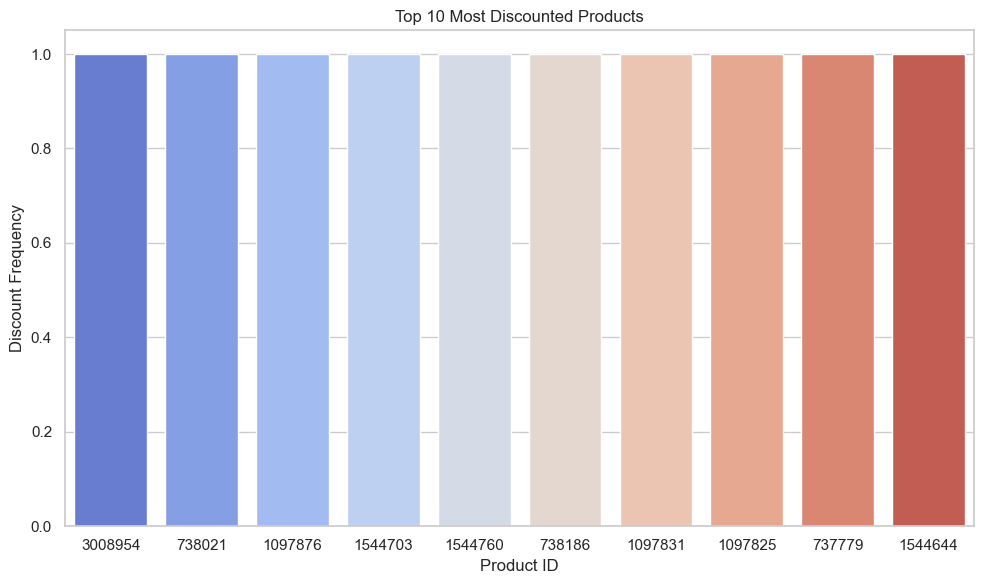

In [23]:
customer_summary['LoyaltyScore'] = customer_summary['TotalSpent'] * customer_summary['TotalBaskets']
print("\nCustomer Loyalty Summary:")
print(customer_summary.head())



#top loyal customers
top_customers = customer_summary.sort_values('LoyaltyScore', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers['household_key'].astype(str), y=top_customers['LoyaltyScore'], palette="viridis")
plt.xlabel('Customer (household_key)')
plt.ylabel('Loyalty Score')
plt.title('Top 10 Loyal Customers (Loyalty Score)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# Transaction Value Distribution
plt.figure(figsize=(10, 6))
sns.histplot(transactions['SALES_VALUE'], kde=True, color='coral', bins=4)
plt.xlabel('Sales Value')
plt.title('Distribution of Sales Value')
plt.tight_layout()
plt.show()



# Assume a random date with the start date as 2024 01 01

daily_sales = transactions.groupby('DAY')['SALES_VALUE'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='DAY', y='SALES_VALUE', data=daily_sales, marker='o', color='blue')
plt.xlabel('DAY')
plt.ylabel('Total Sales Value')
plt.title('Daily Sales Trend')
plt.tight_layout()
plt.show()


#  Top products 
top_products = transactions.groupby('PRODUCT_ID')['QUANTITY'].sum().reset_index().sort_values('QUANTITY', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products['PRODUCT_ID'].astype(str), y=top_products['QUANTITY'], palette="magma")
plt.xlabel('Product ID')
plt.ylabel('Total Quantity Sold')
plt.title('Top 10 Products by Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quantity vs. Sales Value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='QUANTITY', y='SALES_VALUE', data=transactions, hue='COUPON_DISC', alpha=0.7, palette='coolwarm')
plt.xlabel('Quantity')
plt.ylabel('Sales Value')
plt.title('Quantity vs. Sales Value (by Coupon Usage)')
plt.tight_layout()
plt.show()

def get_time_of_day(time_val):
    hour = int(str(time_val).zfill(4)[:2])
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

transactions['TimeOfDay'] = transactions['TRANS_TIME'].apply(get_time_of_day)

plt.figure(figsize=(8, 6))
sns.countplot(x='TimeOfDay', data=transactions, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='Set2')
plt.title('Transactions by Time of Day')
plt.tight_layout()
plt.show()

# Basket-level Stats
basket_summary = transactions.groupby('BASKET_ID').agg(
    BasketSize=('QUANTITY', 'sum'),
    BasketValue=('SALES_VALUE', 'sum'),
    NumProducts=('PRODUCT_ID', 'nunique'),
).reset_index()

plt.figure(figsize=(10, 6))
sns.histplot(basket_summary['BasketValue'], kde=True, bins=20, color='teal')
plt.xlabel('Basket Value')
plt.title('Distribution of Basket Values')
plt.tight_layout()
plt.show()

# net sepnd = SALES_VALUE + all discounts
transactions['NetSpend'] = transactions['SALES_VALUE'] + transactions['RETAIL_DISC'] + transactions['COUPON_DISC'] + transactions['COUPON_MATCH_DISC']

# RFM
customer_rfm = transactions.groupby('household_key').agg(
    Recency=('DAY', 'max'),
    Frequency=('BASKET_ID', pd.Series.nunique),
    Monetary=('NetSpend', 'sum')
).reset_index()

# normalize for plotting
customer_rfm[['Recency_norm', 'Frequency_norm', 'Monetary_norm']] = customer_rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

plt.figure(figsize=(12, 6))
sns.scatterplot(data=customer_rfm, x='Frequency_norm', y='Monetary_norm', size='Recency_norm', hue='Recency_norm', palette='viridis', sizes=(20, 200))
plt.title('Customer Segmentation: RFM Normalized')
plt.tight_layout()
plt.show()

# Discount analysis
transactions['IsDiscounted'] = (transactions[['RETAIL_DISC', 'COUPON_DISC', 'COUPON_MATCH_DISC']].sum(axis=1) < 0).astype(int)
discount_stats = transactions.groupby('PRODUCT_ID')['IsDiscounted'].mean().reset_index().sort_values(by='IsDiscounted', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=discount_stats, x='PRODUCT_ID', y='IsDiscounted', palette='coolwarm')
plt.title('Top 10 Most Discounted Products')
plt.xlabel('Product ID')
plt.ylabel('Discount Frequency')
plt.tight_layout()
plt.show()




In [24]:

transactions = transactions.copy()

transactions['DAY'] = transactions['DAY'].astype('int16')
transactions['QUANTITY'] = transactions['QUANTITY'].astype('int8')
transactions['WEEK_NO'] = transactions['WEEK_NO'].astype('int8')
transactions['TRANS_TIME'] = transactions['TRANS_TIME'].astype('int16')
transactions['SALES_VALUE'] = transactions['SALES_VALUE'].astype('float32')
transactions['RETAIL_DISC'] = transactions['RETAIL_DISC'].astype('float32')
transactions['COUPON_DISC'] = transactions['COUPON_DISC'].astype('float32')
transactions['COUPON_MATCH_DISC'] = transactions['COUPON_MATCH_DISC'].astype('float32')

transactions = transactions[transactions['DAY'] >= 0]

transactions['TOTAL_DISCOUNT'] = transactions['RETAIL_DISC'] + transactions['COUPON_DISC'] + transactions['COUPON_MATCH_DISC']
transactions['EFFECTIVE_PRICE'] = transactions['SALES_VALUE'] / transactions['QUANTITY']
transactions['DISCOUNT_PCT'] = transactions['TOTAL_DISCOUNT'] / (transactions['SALES_VALUE'] + transactions['TOTAL_DISCOUNT'])
transactions['DISCOUNT_PCT'] = transactions['DISCOUNT_PCT'].fillna(0)

transactions['household_key'] = transactions['household_key'].astype(str)
transactions['PRODUCT_ID'] = transactions['PRODUCT_ID'].astype(str)
transactions['STORE_ID'] = transactions['STORE_ID'].astype(str)
transactions['BASKET_ID'] = transactions['BASKET_ID'].astype(str)

transactions.sort_values(by=['household_key', 'BASKET_ID', 'TRANS_TIME'], inplace=True)

store_sales = transactions.groupby('STORE_ID').agg({
    'SALES_VALUE': 'sum',
    'TOTAL_DISCOUNT': 'sum',
    'QUANTITY': 'sum',
    'BASKET_ID': pd.Series.nunique
}).rename(columns={'BASKET_ID': 'UNIQUE_BASKETS'}).reset_index()

product_stats = transactions.groupby('PRODUCT_ID').agg({
    'SALES_VALUE': 'sum',
    'QUANTITY': 'sum',
    'TOTAL_DISCOUNT': 'sum',
    'BASKET_ID': pd.Series.nunique
}).rename(columns={'BASKET_ID': 'TIMES_PURCHASED'}).reset_index()

household_behavior = transactions.groupby('household_key').agg({
    'SALES_VALUE': 'sum',
    'QUANTITY': 'sum',
    'TOTAL_DISCOUNT': 'sum',
    'BASKET_ID': pd.Series.nunique
}).rename(columns={'BASKET_ID': 'UNIQUE_VISITS'}).reset_index()

basket_summary = transactions.groupby('BASKET_ID').agg({
    'household_key': 'first',
    'SALES_VALUE': 'sum',
    'QUANTITY': 'sum',
    'TOTAL_DISCOUNT': 'sum',
    'PRODUCT_ID': pd.Series.nunique
}).rename(columns={'PRODUCT_ID': 'UNIQUE_ITEMS'}).reset_index()

weekly_stats = transactions.groupby('WEEK_NO').agg({
    'SALES_VALUE': 'sum',
    'QUANTITY': 'sum',
    'BASKET_ID': pd.Series.nunique
}).rename(columns={'BASKET_ID': 'TOTAL_BASKETS'}).reset_index()

transactions['HOUR'] = transactions['TRANS_TIME'] // 60
hourly_sales = transactions.groupby('HOUR').agg({
    'SALES_VALUE': 'sum',
    'BASKET_ID': pd.Series.nunique
}).rename(columns={'BASKET_ID': 'UNIQUE_BASKETS'}).reset_index()

transactions['USED_DISCOUNT'] = transactions['TOTAL_DISCOUNT'] > 0
discount_stats = transactions.groupby('USED_DISCOUNT').agg({
    'SALES_VALUE': 'sum',
    'QUANTITY': 'sum',
    'BASKET_ID': pd.Series.nunique
}).rename(columns={'BASKET_ID': 'BASKET_COUNT'}).reset_index()

top_products = product_stats.sort_values(by='SALES_VALUE', ascending=False).head(10)

average_basket_value = basket_summary['SALES_VALUE'].mean()
average_items_per_basket = basket_summary['QUANTITY'].mean()




In [25]:
print("Store-level Summary:\n", store_sales.head(), "\n")
print("Top 10 Products by Sales:\n", top_products, "\n")
print("Household Purchase Summary:\n", household_behavior.head(), "\n")
print("Basket Stats Example:\n", basket_summary.head(), "\n")

print(f"Avg Basket Value: {average_basket_value:.2f}")
print(f"Avg Items per Basket: {average_items_per_basket:.2f}")

Store-level Summary:
   STORE_ID  SALES_VALUE  TOTAL_DISCOUNT  QUANTITY  UNIQUE_BASKETS
0        1    24.889999           -0.72        83               2
1     1018    10.260000           -2.62        12               1
2     1027     5.050000            0.00         5               1
3     1039    49.540001          -15.87        35               5
4      105   109.930000          -14.30        38               5 

Top 10 Products by Sales:
       PRODUCT_ID    SALES_VALUE  QUANTITY  TOTAL_DISCOUNT  TIMES_PURCHASED
40940    6534178  111386.671875    296578    -3954.679932             4660
4113     1029743   20398.689453      8502    -1576.140015             7195
10330    1082185   14730.410156     15330    -1081.380005            14742
57340     916122   14586.299805      3523   -15047.160156             2189
12709    1106523   13916.110352      5810    -1033.030029             4966
40898    6533765   13042.959961       823        0.000000              823
70354     995242   12825.469

In [26]:
print("Weekly Sales:\n", weekly_stats.head(), "\n")
print("Hourly Sales Pattern:\n", hourly_sales.head(), "\n")
print("Discount Usage Comparison:\n", discount_stats, "\n")

Weekly Sales:
    WEEK_NO   SALES_VALUE  QUANTITY  TOTAL_BASKETS
0        1   5211.160156      2353            139
1        2  10815.969727      4767            319
2        3  13454.929688      6449            477
3        4  15927.929688      7102            542
4        5  20018.199219      9216            747 

Hourly Sales Pattern:
    HOUR   SALES_VALUE  UNIQUE_BASKETS
0     0  23963.480469            1015
1     1   4511.529785             190
2     2   7432.140137             337
3     3   5024.089844             457
4     4   2585.350098             127 

Discount Usage Comparison:
    USED_DISCOUNT  SALES_VALUE  QUANTITY  BASKET_COUNT
0          False   3847915.50   2017736        131442
1           True         8.98         5             2 



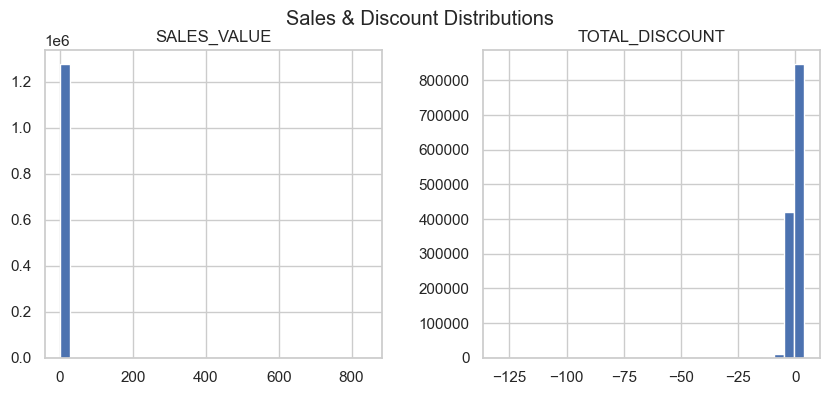

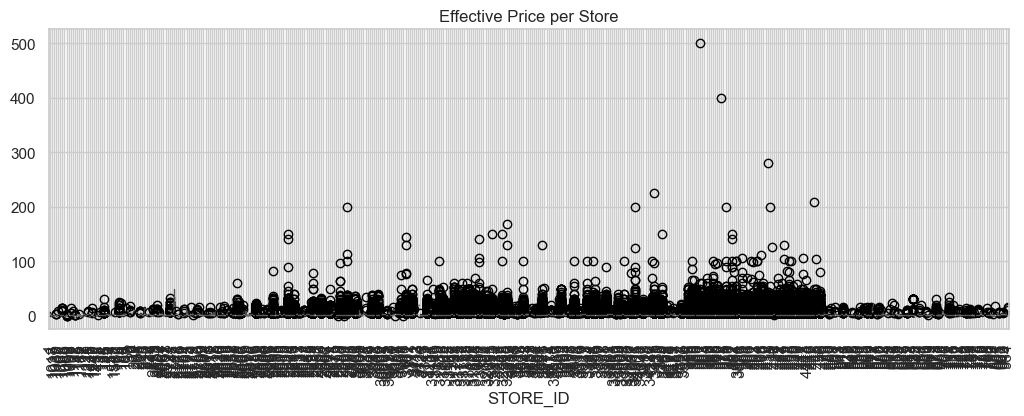

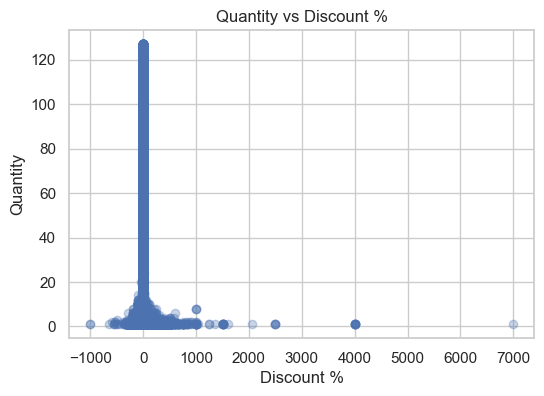

In [27]:
import matplotlib.pyplot as plt

transactions[['SALES_VALUE','TOTAL_DISCOUNT']].hist(bins=30, figsize=(10,4))
plt.suptitle("Sales & Discount Distributions"); plt.show()

transactions.boxplot(column='EFFECTIVE_PRICE', by='STORE_ID', rot=90, figsize=(12,4))
plt.title("Effective Price per Store"); plt.suptitle(""); plt.show()

plt.figure(figsize=(6,4))
plt.scatter(transactions['DISCOUNT_PCT'], transactions['QUANTITY'], alpha=0.3)
plt.xlabel("Discount %"); plt.ylabel("Quantity"); plt.title("Quantity vs Discount %"); plt.show()


In [28]:




start_date = pd.to_datetime('2020-01-01')  

transactions['Date'] = start_date + pd.to_timedelta(transactions['DAY'], unit='D')

transactions['Time'] = pd.to_timedelta(transactions['TRANS_TIME'], unit='m')

transactions['Datetime'] = transactions['Date'] + transactions['Time']


C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2547553722.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = transactions.set_index('Datetime').resample('M').agg({'SALES_VALUE':'sum'}).reset_index()


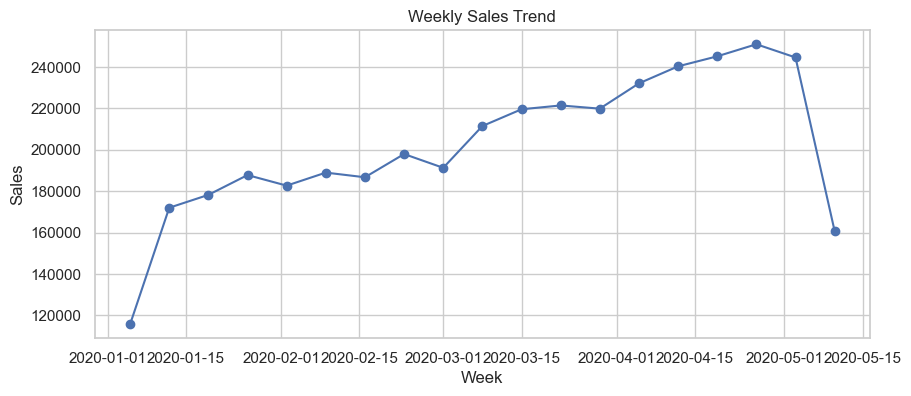

In [29]:
transactions['Datetime'] = pd.to_datetime(transactions['Datetime'])

daily = transactions.set_index('Datetime').resample('D').agg({'SALES_VALUE':'sum'}).reset_index()

weekly = transactions.set_index('Datetime').resample('W').agg(
    SALES_VALUE=('SALES_VALUE','sum'),
    BASKETS=('BASKET_ID','nunique')
).reset_index()

monthly = transactions.set_index('Datetime').resample('M').agg({'SALES_VALUE':'sum'}).reset_index()

# Plot weekly trend
plt.figure(figsize=(10,4))
plt.plot(weekly['Datetime'], weekly['SALES_VALUE'], marker='o')
plt.title("Weekly Sales Trend"); plt.xlabel("Week"); plt.ylabel("Sales"); plt.show()


In [30]:
import pandas as pd

# Reference date = day after the last transaction
snapshot = transactions['Datetime'].max() + pd.Timedelta(days=1)

rfm = transactions.groupby('household_key').agg(
    recency=('Datetime', lambda x: (snapshot - x.max()).days),
    frequency=('BASKET_ID', 'nunique'),
    monetary=('SALES_VALUE', 'sum')
).reset_index()

def safe_qcut(series, q, labels, reverse=False):
    unique_vals = series.nunique()
    bins = min(q, unique_vals)
    try:
        scored = pd.qcut(series, q=bins, labels=labels[:bins], duplicates='drop')
        return scored.astype(int) if not reverse else scored.astype(int).map(lambda x: labels[bins - 1 - x])
    except ValueError:
        return pd.Series([labels[bins//2]] * len(series))  # Assign middle label if all else fails

rfm['R_Score'] = safe_qcut(rfm['recency'], 4, labels=[4, 3, 2, 1], reverse=False)
rfm['F_Score'] = safe_qcut(rfm['frequency'], 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = safe_qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

top_customers = rfm.sort_values(by='RFM_Score', ascending=False).head()
print(top_customers)


     household_key  recency  frequency     monetary  R_Score  F_Score  \
1727           304        1        146  4242.629883        2        4   
1517          2366        2         73  2563.399902        2        4   
290           1260        3         88  6092.580078        2        4   
2215           745        2         93  3235.679932        2        4   
620           1558        3         87  2848.800049        2        4   

      M_Score RFM_Segment  RFM_Score  
1727        4         244         10  
1517        4         244         10  
290         4         244         10  
2215        4         244         10  
620         4         244         10  


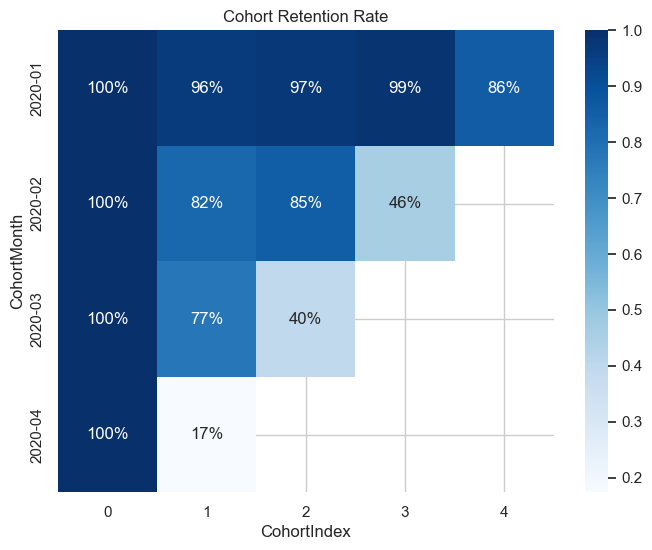

In [31]:
transactions['InvoiceMonth'] = transactions['Datetime'].dt.to_period('M')
transactions.set_index('household_key', inplace=False)

cohort = transactions.groupby('household_key')['InvoiceMonth'].min().reset_index()
cohort.columns = ['household_key','CohortMonth']

trans_cohort = transactions.merge(cohort, on='household_key')

trans_cohort['CohortIndex'] = (
    (trans_cohort['InvoiceMonth'] - trans_cohort['CohortMonth'])
).apply(lambda x: x.n)

cohort_data = trans_cohort.groupby(['CohortMonth','CohortIndex'])['household_key'] \
    .nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth',columns='CohortIndex',values='household_key')
retention = cohort_counts.divide(cohort_counts.iloc[:,0], axis=0)

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues')
plt.title("Cohort Retention Rate"); plt.show()
# Cohort analysis measures retention over time :contentReference[oaicite:3]{index=3}


In [32]:
prod = transactions.groupby('PRODUCT_ID')['SALES_VALUE'].sum().reset_index()

prod = prod.sort_values('SALES_VALUE', ascending=False)
prod['cum_pct'] = prod['SALES_VALUE'].cumsum() / prod['SALES_VALUE'].sum()

def abc_cat(pct):
    if pct <= 0.8: return 'A'
    elif pct <= 0.95: return 'B'
    else: return 'C'

prod['ABC_Category'] = prod['cum_pct'].apply(abc_cat)
print(prod['ABC_Category'].value_counts())
# ABC analysis classifies items into A/B/C by cumulative contribution :contentReference[oaicite:4]{index=4}


ABC_Category
C    39118
B    19537
A    12225
Name: count, dtype: int64


In [33]:
# import pandas as pd
# import numpy as np
# from mlxtend.frequent_patterns import apriori, association_rules
# import scipy.sparse as sp

# # Load the data
# transactions = pd.read_csv("transaction_data.csv")

# # Data preprocessing and cleaning
# transactions_clean = transactions.copy()
# transactions_clean['PRODUCT_ID'] = transactions_clean['PRODUCT_ID'].astype(str)  # Ensure PRODUCT_ID is a string

# sampled_data = transactions_clean.sample(frac=0.1, random_state=42)  # Sampling 10% of the data

# basket = sampled_data.groupby(['BASKET_ID', 'PRODUCT_ID'])['QUANTITY'].sum().reset_index()


# basket_matrix = basket.pivot_table(index='BASKET_ID', columns='PRODUCT_ID', values='QUANTITY', aggfunc='sum', fill_value=0)


# basket_matrix = basket_matrix.applymap(lambda x: 1 if x > 0 else 0)


# duplicate_combinations = basket[basket.duplicated(subset=['BASKET_ID', 'PRODUCT_ID'], keep=False)]
# if not duplicate_combinations.empty:
#     print(f"Found {duplicate_combinations.shape[0]} duplicate combinations")
# else:
#     print("No duplicate combinations found")

# basket_matrix_sparse = sp.csr_matrix(basket_matrix.values)

# frequent_itemsets = apriori(basket_matrix, min_support=0.01, use_colnames=True)

# rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# # Print some sample results
# print("Sample of frequent itemsets:")
# print(frequent_itemsets.head())

# print("\nSample of association rules:")
# print(rules.head())


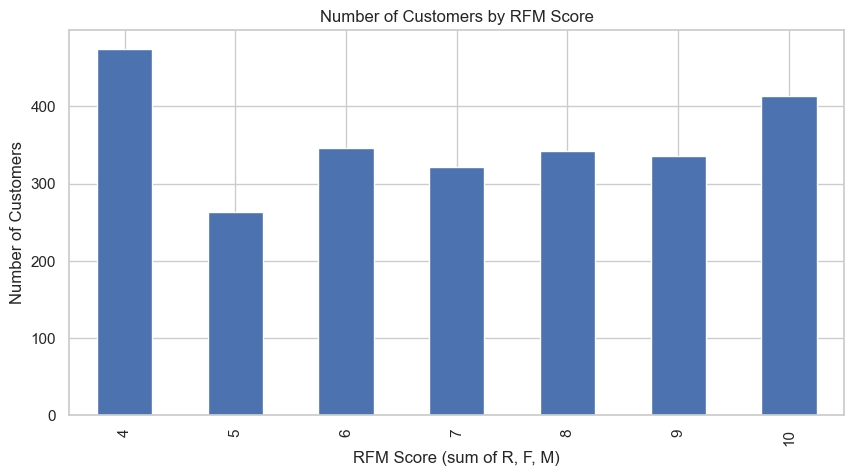

In [34]:
import matplotlib.pyplot as plt

rfm['RFM_Score'] = rfm['RFM_Score'].astype(int)
rfm['RFM_Score'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5))
plt.title('Number of Customers by RFM Score')
plt.xlabel('RFM Score (sum of R, F, M)')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()


In [35]:
def segment_customer(row):
    if row['RFM_Score'] >= 10:
        return 'Champions'
    elif row['RFM_Score'] >= 7:
        return 'Loyal'
    elif row['RFM_Score'] >= 4:
        return 'Potential'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)


In [36]:


# # Ensure datetime is in correct format
# transactions['Datetime'] = pd.to_datetime(transactions['DAY'].astype(str) + ' ' + transactions['TRANS_TIME'].astype(str), format='%d %H%M')

# transactions['Datetime'] = pd.to_datetime(transactions['Datetime'])

# ### -------------------- 1. STORE-LEVEL SUMMARY --------------------
# store_summary = transactions.groupby('STORE_ID').agg({
#     'SALES_VALUE': 'sum',
#     'BASKET_ID': pd.Series.nunique,
#     'household_key': pd.Series.nunique
# }).rename(columns={
#     'SALES_VALUE': 'Total_Sales',
#     'BASKET_ID': 'Total_Transactions',
#     'household_key': 'Unique_Customers'
# }).reset_index()

# print(" Store-Level Summary:\n", store_summary.head())

# ### -------------------- 2. PRODUCT-LEVEL SUMMARY --------------------
# product_summary = transactions.groupby('PRODUCT_ID').agg({
#     'SALES_VALUE': 'sum',
#     'BASKET_ID': pd.Series.nunique,
#     'household_key': pd.Series.nunique
# }).rename(columns={
#     'SALES_VALUE': 'Total_Sales',
#     'BASKET_ID': 'Total_Transactions',
#     'household_key': 'Unique_Customers'
# }).reset_index().sort_values(by='Total_Sales', ascending=False)

# print("\n Product-Level Summary (Top 5 Products):\n", product_summary.head())

# ### -------------------- 3. TEMPORAL TRENDS --------------------
# transactions['Hour'] = transactions['Datetime'].dt.hour
# transactions['Date'] = transactions['Datetime'].dt.date

# # Hourly
# hourly_sales = transactions.groupby('Hour')['SALES_VALUE'].sum()
# plt.figure(figsize=(10,4))
# sns.lineplot(x=hourly_sales.index, y=hourly_sales.values)
# plt.title('Hourly Sales Trend')
# plt.xlabel('Hour of Day')
# plt.ylabel('Sales')
# plt.grid(True)
# plt.show()

# # Daily
# daily_sales = transactions.groupby('Date')['SALES_VALUE'].sum()
# plt.figure(figsize=(12,4))
# sns.lineplot(x=daily_sales.index, y=daily_sales.values)
# plt.title('Daily Sales Trend')
# plt.xlabel('Date')
# plt.ylabel('Sales')
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# ### -------------------- 4. RFM ANALYSIS --------------------
# # Reference date
# snapshot = transactions['Datetime'].max() + pd.Timedelta(days=1)

# # RFM Values
# rfm = transactions.groupby('household_key').agg(
#     recency=('Datetime', lambda x: (snapshot - x.max()).days),
#     frequency=('BASKET_ID', 'nunique'),
#     monetary=('SALES_VALUE', 'sum')
# ).reset_index()

# # Safe qcut function
# def safe_qcut(series, q, labels, reverse=False):
#     unique_vals = series.nunique()
#     bins = min(q, unique_vals)
#     try:
#         scored = pd.qcut(series, q=bins, labels=labels[:bins], duplicates='drop')
#         return scored.astype(int) if not reverse else scored.astype(int).map(lambda x: labels[bins - 1 - x])
#     except ValueError:
#         return pd.Series([labels[bins//2]] * len(series))  # fallback: assign middle score

# # RFM Scores
# rfm['R_Score'] = safe_qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])
# rfm['F_Score'] = safe_qcut(rfm['frequency'], 4, labels=[1, 2, 3, 4])
# rfm['M_Score'] = safe_qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

# # Segment and score
# rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
# rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

# # Define basic segments (optional - simple example)
# def segment_customer(row):
#     if row['RFM_Score'] >= 10:
#         return 'Champions'
#     elif row['RFM_Score'] >= 7:
#         return 'Loyal'
#     elif row['RFM_Score'] >= 5:
#         return 'Potential'
#     else:
#         return 'At Risk'

# rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# # Segment Distribution
# segment_counts = rfm['Segment'].value_counts()
# print("\n Customer Segments:\n", segment_counts)

# plt.figure(figsize=(6,4))
# sns.countplot(y='Segment', data=rfm, order=segment_counts.index, palette='coolwarm')
# plt.title('Customer Segment Distribution')
# plt.xlabel('Number of Customers')
# plt.ylabel('Segment')
# plt.grid(True, axis='x')
# plt.tight_layout()
# plt.show()

# # Top Customers
# top_customers = rfm.sort_values(by='RFM_Score', ascending=False).head()
# print(" Top 5 Customers based on RFM Score:\n", top_customers)



In [37]:


# Create derived features
transactions['NET_SALES'] = transactions['SALES_VALUE'] + transactions['RETAIL_DISC'] + transactions['COUPON_DISC'] + transactions['COUPON_MATCH_DISC']

# Aggregate per household or basket
basket_features = transactions.groupby(['household_key', 'BASKET_ID']).agg({
    'DAY': 'first',
    'QUANTITY': 'sum',
    'SALES_VALUE': 'sum',
    'RETAIL_DISC': 'sum',
    'COUPON_DISC': 'sum',
    'COUPON_MATCH_DISC': 'sum',
    'NET_SALES': 'sum',
    'TRANS_TIME': 'mean',
    'WEEK_NO': 'first',
    'STORE_ID': 'nunique',
    'PRODUCT_ID': 'nunique'
}).reset_index()

# Rename columns for clarity
basket_features.columns = ['household_key', 'basket_id', 'day', 'total_quantity', 'total_sales', 
                           'retail_disc', 'coupon_disc', 'coupon_match_disc', 'net_sales',
                           'avg_trans_time', 'week_no', 'store_count', 'unique_products']


In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = basket_features.drop(['household_key', 'basket_id'], axis=1)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
basket_features['cluster'] = kmeans.fit_predict(X_scaled)


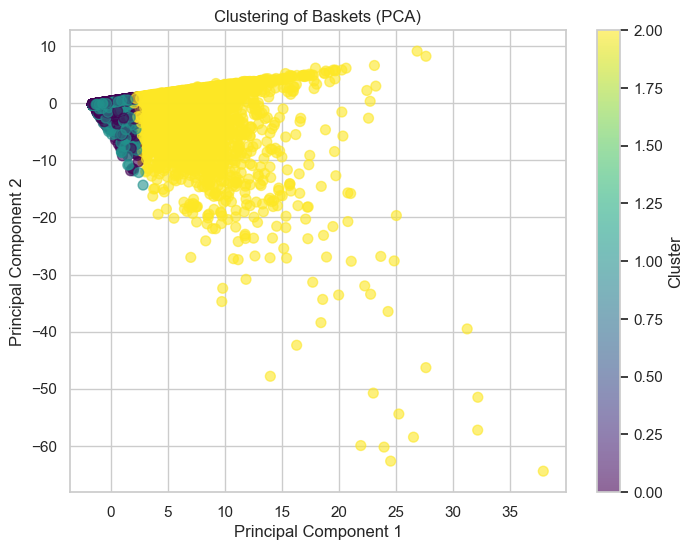

In [39]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA to reduce the features to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotting the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=basket_features['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.title('Clustering of Baskets (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()


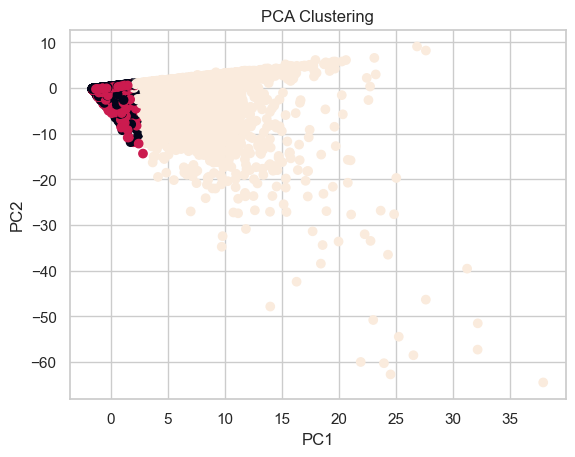

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.scatter(components[:, 0], components[:, 1], c=basket_features['cluster'])
plt.title("PCA Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [41]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create a label
threshold = basket_features['net_sales'].median()
basket_features['high_spender'] = np.where(basket_features['net_sales'] > threshold, 1, 0)

# Model
X = basket_features.drop(['household_key', 'basket_id', 'net_sales', 'high_spender'], axis=1)
y = basket_features['high_spender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00     19623
           1       0.99      1.00      1.00     19810

    accuracy                           1.00     39433
   macro avg       1.00      1.00      1.00     39433
weighted avg       1.00      1.00      1.00     39433



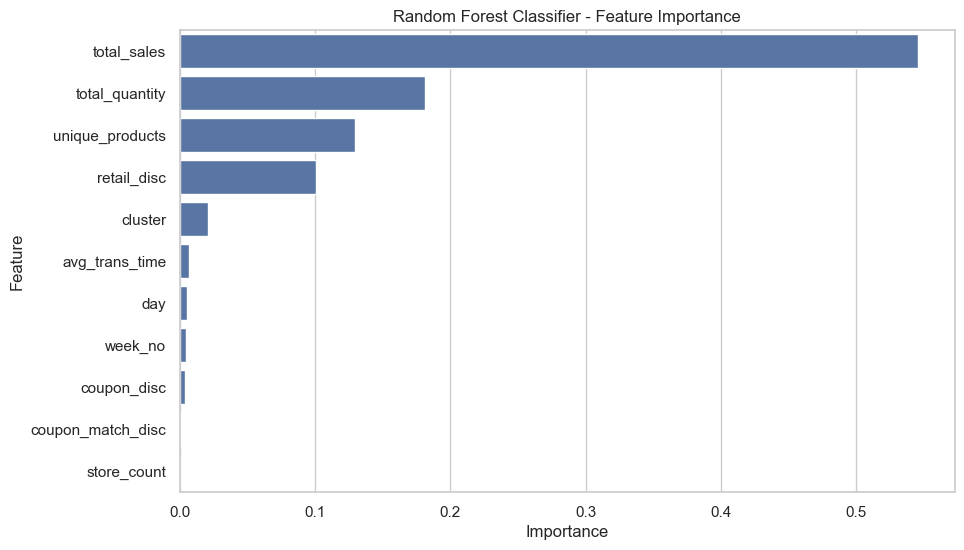

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importances = clf.feature_importances_
feature_names = X.columns

# Sort feature importance
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Random Forest Classifier - Feature Importance')
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = basket_features.drop(['household_key', 'basket_id', 'net_sales'], axis=1)
y = basket_features['net_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")


MSE: 0.0000


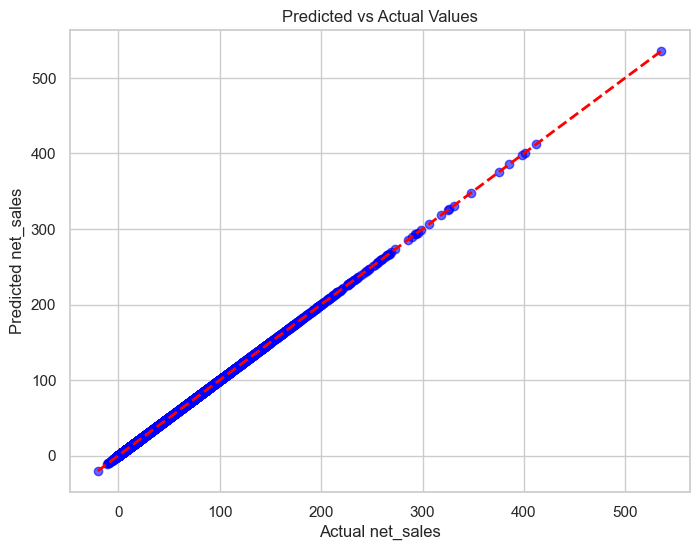

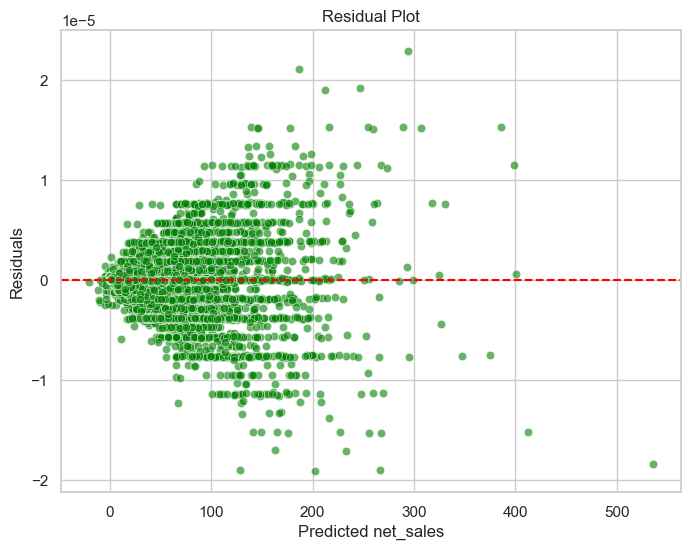

MSE: 0.0000


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual net_sales')
plt.ylabel('Predicted net_sales')
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted net_sales')
plt.ylabel('Residuals')
plt.show()

# Print MSE
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")


In [45]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
basket_features['anomaly'] = iso.fit_predict(X_scaled)


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1: Prepare Data
threshold = basket_features['net_sales'].median()
basket_features['high_spender'] = (basket_features['net_sales'] > threshold).astype(int)

X = basket_features.drop(columns=['household_key', 'basket_id', 'net_sales', 'high_spender'])
y = basket_features['high_spender'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Step 2: Define Model
class BasketNet(nn.Module):
    def __init__(self, input_size):
        super(BasketNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = BasketNet(input_size=X_train.shape[1])

# Step 3: Loss & Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 4: Train the Model
epochs = 20
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Step 5: Evaluate
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_labels = (predictions > 0.5).float()
    accuracy = (predicted_labels == y_test_tensor).float().mean()
    print(f"\nTest Accuracy: {accuracy.item() * 100:.2f}%")


Epoch [5/20], Loss: 0.6753
Epoch [10/20], Loss: 0.6544
Epoch [15/20], Loss: 0.6324
Epoch [20/20], Loss: 0.6074

Test Accuracy: 79.62%


In [47]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

# Load the original transaction data
transactions = pd.read_csv("transaction_data.csv")

# Calculate net_sales per basket
transactions['net_sales'] = transactions['SALES_VALUE'] + transactions['RETAIL_DISC'] + transactions['COUPON_DISC'] + transactions['COUPON_MATCH_DISC']

# Aggregate to basket level
basket_data = transactions.groupby(['household_key', 'BASKET_ID', 'DAY']).agg({
    'net_sales': 'sum',
    'QUANTITY': 'sum',
    'TRANS_TIME': 'mean',
    'STORE_ID': 'first',
}).reset_index()

# Sort baskets by time
basket_data.sort_values(by=['household_key', 'DAY'], inplace=True)

# Normalize numerical features
scaler = StandardScaler()
basket_data[['net_sales', 'QUANTITY', 'TRANS_TIME']] = scaler.fit_transform(basket_data[['net_sales', 'QUANTITY', 'TRANS_TIME']])

# Step 1: Create sequences of baskets for each household
sequence_length = 3  # use 3 previous baskets to predict the 4th

sequences = []
targets = []

for hh, group in basket_data.groupby('household_key'):
    group = group.reset_index(drop=True)
    for i in range(len(group) - sequence_length):
        seq = group.iloc[i:i+sequence_length][['net_sales', 'QUANTITY', 'TRANS_TIME']].values
        target = group.iloc[i+sequence_length]['net_sales']
        sequences.append(seq)
        targets.append(target)

# Convert to PyTorch Dataset
class BasketSequenceDataset(Dataset):
    def __init__(self, sequences, targets):
        self.X = torch.tensor(sequences, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = BasketSequenceDataset(sequences, targets)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Step 2: Define LSTM model
class BasketLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super(BasketLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # take last output
        return self.fc(out)

model = BasketLSTM(input_dim=3, hidden_dim=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Step 3: Training loop
for epoch in range(20):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader):.4f}")


C:\Users\gratu\AppData\Local\Temp\ipykernel_47732\2406536109.py:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:277.)
  self.X = torch.tensor(sequences, dtype=torch.float32)


Epoch 1, Loss: 0.8681
Epoch 2, Loss: 0.8655
Epoch 3, Loss: 0.8671
Epoch 4, Loss: 0.8643
Epoch 5, Loss: 0.8637
Epoch 6, Loss: 0.8633
Epoch 7, Loss: 0.8631
Epoch 8, Loss: 0.8625
Epoch 9, Loss: 0.8622
Epoch 10, Loss: 0.8622
Epoch 11, Loss: 0.8621
Epoch 12, Loss: 0.8617
Epoch 13, Loss: 0.8612
Epoch 14, Loss: 0.8609
Epoch 15, Loss: 0.8607
Epoch 16, Loss: 0.8602
Epoch 17, Loss: 0.8596
Epoch 18, Loss: 0.8594
Epoch 19, Loss: 0.8587
Epoch 20, Loss: 0.8586
